In [1]:
# Import Pandas for loading and analyzing the Netflix dataset.
import pandas as pd

In [2]:
#read file
df = pd.read_csv("data/netflix_titles.csv")

print(df.head())
# Display the names of all columns in the dataset. , This helps us understand what information is available for analysis.
print(df.columns)


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
# Display the number of rows and columns in the dataset. , This tells us how many Netflix records we have , and how many variables (columns) are available.
print(df.shape)

# Display information about each column, including ,its data type and the number of non-empty values., This helps us understand the structure and identify , possible missing values.
df.info()

(8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [4]:
# Count the number of missing (empty) values in each column./ This helps us identify which columns need data cleaning.
print(df.isnull().sum())

# Count the number of completely duplicate rows in the dataset. , This helps us check whether the same Netflix record appears more than once.
print(df.duplicated().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
0


In [5]:
# Display basic statistical information about numerical columns. This helps us understand values such as the minimum year, maximum year, average year, and how the years are distributed.
print(df.describe())

# Count how many titles belong to each content type. This tells us how many Movies and TV Shows are in the dataset.
print(df["type"].value_counts())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [6]:
# Calculate the percentage of each content type in the dataset. This helps us compare Movies and TV Shows more clearly.
print(df["type"].value_counts(normalize=True) * 100)

# Count how many titles have each content rating. This helps us understand the age/classification distribution of Netflix content.
print(df["rating"].value_counts())

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [7]:
# Find rows where the rating column contains values that look like durations.
# This helps us identify the incorrect records before cleaning the data.
print(df[df["rating"].isin(["74 min", "84 min", "66 min"])][["title", "type", "rating", "duration"]])

# Count the missing values in the duration column.This helps us determine how many duration values are unavailable, and whether the incorrect rating values can be used to recover them.
print(df["duration"].isnull().sum())


                                     title   type  rating duration
5541                       Louis C.K. 2017  Movie  74 min      NaN
5794                 Louis C.K.: Hilarious  Movie  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  Movie  66 min      NaN
3


In [8]:
# Count each rating separately for Movies and TV Shows.This helps us understand how content ratings differ between the two content types.
print(pd.crosstab(df["rating"], df["type"]))

# Count the number of titles associated with each country. This helps us identify the countries with the largest amount of Netflix content.
print(df["country"].value_counts().head(10))

# Count the most common genres listed in the dataset. This helps us understand which types of content appear most frequently on Netflix.
print(df["listed_in"].value_counts().head(10))

type      Movie  TV Show
rating                  
66 min        1        0
74 min        1        0
84 min        1        0
G            41        0
NC-17         3        0
NR           75        5
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      733
TV-G        126       94
TV-MA      2062     1145
TV-PG       540      323
TV-Y        131      176
TV-Y7       139      195
TV-Y7-FV      5        1
UR            3        0
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies,

In [9]:
# Convert the date_added column into a proper date format. This allows us to extract the year and analyze Netflix's content additions over time.
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Count how many titles were added to Netflix in each year. This helps us identify trends in Netflix's content additions over time.
print(df["date_added"].dt.year.value_counts().sort_index())

# Count how many titles are associated with each director.This helps us identify directors who appear most frequently in the Netflix dataset.
print(df["director"].value_counts().head(10))

# Count Movies and TV Shows for each release year. This helps us compare how the types of Netflix content ,have changed across different years.
print(pd.crosstab(df["release_year"], df["type"]).tail(15))

# Select only Movie records and count their duration values. This helps us understand the typical length of Netflix movies.
print(df[df["type"] == "Movie"]["duration"].value_counts().head(15))

# Select only TV Show records and count their season durations.
# This helps us understand how many seasons TV Shows typically have.
print(df[df["type"] == "TV Show"]["duration"].value_counts().head(10))

# Count Movies and TV Shows added to Netflix for each year.This helps us compare the growth of both content types over time.
print(df.groupby([df["date_added"].dt.year, "type"]).size().unstack(fill_value=0))

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64
type          Movie  TV Show
release_year                
2007             74       14
2008            113       23
2009            118       34
2010            154       40
2011            145       40
2012            173       64
2013            225       63
2014            264       88
2015            398      162
2016            658      244
2017            767      265
2018            767      380
2019            633   

In [10]:
# Calculate the percentage of Movies and TV Shows added in each year. This lets us compare the composition of Netflix's yearly additions, even when the total number of additions changes from year to year.
yearly_type_percentage = df.groupby([df["date_added"].dt.year, "type"]).size().groupby(level=0).apply(lambda x: x / x.sum() * 100)

# Display the yearly percentages. This helps us see whether Netflix's yearly additions are becoming, relatively more focused on Movies or TV Shows.
print(yearly_type_percentage)

# Count how many titles were added to Netflix in each year.
# This gives us the total yearly additions needed to measure growth.
yearly_additions = df["date_added"].dt.year.value_counts().sort_index()

# Calculate the percentage change in additions compared with the previous year.
# This helps us identify years of rapid growth or decline in Netflix's catalog additions.
yearly_growth = yearly_additions.pct_change() * 100

# Display the yearly additions and their percentage change.
# This allows us to identify the major expansion and slowdown periods.
print(pd.DataFrame({
    "Total Additions": yearly_additions,
    "Growth (%)": yearly_growth
}))

# Extract the numeric part from the duration column.
# This converts values such as "90 min" and "2 Seasons" into numbers.
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)

# Display the minimum and maximum duration values for Movies.
# This helps us detect unusually short or unusually long movie durations.
print(df[df["type"] == "Movie"]["duration_value"].describe())

# Sort Movies by their numeric duration from shortest to longest.
# This helps us identify unusually short movie records.
shortest_movies = df[df["type"] == "Movie"].sort_values("duration_value").head(10)

# Display the 10 shortest Movies with their titles and durations.
# This lets us inspect whether these unusual values are valid or possible data issues.
print(shortest_movies[["title", "duration", "duration_value"]])

# Sort Movies by their numeric duration from longest to shortest.
# This helps us identify unusually long movie records.
longest_movies = df[df["type"] == "Movie"].sort_values("duration_value", ascending=False).head(10)

# Display the 10 longest Movies with their titles and durations.
# This lets us inspect the extreme values in the dataset.
print(longest_movies[["title", "duration", "duration_value"]])

date_added  date_added  type   
2008.0      2008.0      Movie       50.000000
                        TV Show     50.000000
2009.0      2009.0      Movie      100.000000
2010.0      2010.0      Movie      100.000000
2011.0      2011.0      Movie      100.000000
2012.0      2012.0      Movie      100.000000
2013.0      2013.0      Movie       60.000000
                        TV Show     40.000000
2014.0      2014.0      Movie       82.608696
                        TV Show     17.391304
2015.0      2015.0      Movie       76.712329
                        TV Show     23.287671
2016.0      2016.0      Movie       60.526316
                        TV Show     39.473684
2017.0      2017.0      Movie       72.079038
                        TV Show     27.920962
2018.0      2018.0      Movie       76.123077
                        TV Show     23.876923
2019.0      2019.0      Movie       71.235618
                        TV Show     28.764382
2020.0      2020.0      Movie       68.370607
  

In [11]:
# Calculate the first quartile (Q1) of movie durations.
# Q1 represents the point below which 25% of movies fall.
Q1 = df[df["type"] == "Movie"]["duration_value"].quantile(0.25)

# Calculate the third quartile (Q3) of movie durations.
# Q3 represents the point below which 75% of movies fall.
Q3 = df[df["type"] == "Movie"]["duration_value"].quantile(0.75)

# Calculate the interquartile range (IQR).
# IQR measures the spread of the middle 50% of movie durations.
IQR = Q3 - Q1

# Calculate the lower boundary for potential statistical outliers.
# Values below this boundary are unusually short according to the IQR method.
lower_bound = Q1 - 1.5 * IQR

# Calculate the upper boundary for potential statistical outliers.
# Values above this boundary are unusually long according to the IQR method.
upper_bound = Q3 + 1.5 * IQR

# Display the calculated boundaries.
# This helps us understand what duration range is considered statistically typical.
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Select movies whose duration is below the lower statistical boundary
# or above the upper statistical boundary.
# This identifies movies that are statistical outliers.
duration_outliers = df[
    (df["type"] == "Movie") &
    ((df["duration_value"] < lower_bound) |
     (df["duration_value"] > upper_bound))
]

# Count the number of statistical duration outliers.
# This tells us how common unusual movie lengths are in the dataset.
print("Number of duration outliers:", len(duration_outliers))

# Calculate the percentage of movies that are statistical duration outliers.
# This tells us how significant the unusual-duration group is within all movies.
outlier_percentage = len(duration_outliers) / len(df[df["type"] == "Movie"]) * 100

# Display the percentage of movies classified as duration outliers.
# This helps us interpret whether the outliers represent a small or substantial part of the dataset.
print("Duration outliers (%):", outlier_percentage)

# Count movies that are below the lower statistical boundary.
# This tells us how many outliers are unusually short.
short_outliers = len(duration_outliers[duration_outliers["duration_value"] < lower_bound])

# Count movies that are above the upper statistical boundary.
# This tells us how many outliers are unusually long.
long_outliers = len(duration_outliers[duration_outliers["duration_value"] > upper_bound])

# Display the number of short and long duration outliers.
# This helps us understand which type of unusual duration is more common.
print("Short outliers:", short_outliers)
print("Long outliers:", long_outliers)

# Select the 10 shortest movie outliers.
# This helps us inspect whether very short movies are legitimate content
# or possible data-quality problems.
shortest_outliers = duration_outliers[
    duration_outliers["duration_value"] < lower_bound
].sort_values("duration_value").head(10)

# Display the titles, durations, and descriptions of these short outliers.
# The descriptions help us understand what kind of content these short titles represent.
print(shortest_outliers[["title", "duration", "description"]])

Lower Bound: 46.5
Upper Bound: 154.5
Number of duration outliers: 450
Duration outliers (%): 7.339748817484913
Short outliers: 249
Long outliers: 201
                                                  title duration  \
3777                                             Silent    3 min   
2713                                        Sol Levante    5 min   
1484                                   Cops and Robbers    8 min   
1557                                             Canvas    9 min   
3535   American Factory: A Conversation with the Obamas   10 min   
2858  Calico Critters: Everyone's Big Dream Flying i...   11 min   
6405                  Calico Critters: A Town of Dreams   11 min   
695                                      Besieged Bread   12 min   
4707                                               Zion   12 min   
3775                     Cosmos Laundromat: First Cycle   12 min   

                                            description  
3777  "Silent" is an animated short film cr

In [12]:
# Select the 10 longest movie outliers.
# This helps us inspect whether unusually long movies are legitimate content
# or possible data-quality problems.
longest_outliers = duration_outliers[
    duration_outliers["duration_value"] > upper_bound
].sort_values("duration_value", ascending=False).head(10)

# Display the titles, durations, and descriptions of these long outliers.
# The descriptions help us understand why these movies have unusually long durations.
print(longest_outliers[["title", "duration", "description"]])

                            title duration  \
4253   Black Mirror: Bandersnatch  312 min   
717   Headspace: Unwind Your Mind  273 min   
2491       The School of Mischief  253 min   
2487               No Longer kids  237 min   
2484           Lock Your Girls In  233 min   
2488              Raya and Sakina  230 min   
166   Once Upon a Time in America  229 min   
7932                       Sangam  228 min   
1019                       Lagaan  224 min   
4573                 Jodhaa Akbar  214 min   

                                            description  
4253  In 1984, a young programmer begins to question...  
717   Do you want to relax, meditate or sleep deeply...  
2491  A high school teacher volunteers to transform ...  
2487  Hoping to prevent their father from skipping t...  
2484  A widower believes he must marry off his three...  
2488  When robberies and murders targeting women swe...  
166   Director Sergio Leone's sprawling crime epic f...  
7932  Returning home from war

In [13]:
# Split the listed_in column at ", " so each genre becomes a separate value.
# This allows us to count individual genres instead of genre combinations.
genres = df["listed_in"].str.split(", ").explode()

# Count how many Netflix titles are associated with each individual genre.
# This helps us identify the most common content categories on Netflix.
genre_counts = genres.value_counts()

# Display the 15 most common individual genres.
# This gives us a clearer picture of Netflix's content mix.
print(genre_counts.head(15))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64


In [14]:
# Split each title's genre combinations into individual genres.
# This allows us to compare individual genres across Movies and TV Shows.
genre_by_type = df.assign(
    genre=df["listed_in"].str.split(", ")
).explode("genre").reset_index(drop=True)

# Count each individual genre separately for Movies and TV Shows.
# This creates a table showing the content type distribution of each genre.
genre_type_counts = pd.crosstab(
    genre_by_type["genre"],
    genre_by_type["type"]
)

# Calculate the total number of titles associated with each genre.
# This helps us identify the most common genres overall.
genre_type_counts["Total"] = genre_type_counts.sum(axis=1)

# Sort genres from highest to lowest total count.
# This makes the most common genres appear first.
print(genre_type_counts.sort_values("Total", ascending=False).head(15))

type                      Movie  TV Show  Total
genre                                          
International Movies       2752        0   2752
Dramas                     2427        0   2427
Comedies                   1674        0   1674
International TV Shows        0     1351   1351
Documentaries               869        0    869
Action & Adventure          859        0    859
TV Dramas                     0      763    763
Independent Movies          756        0    756
Children & Family Movies    641        0    641
Romantic Movies             616        0    616
TV Comedies                   0      581    581
Thrillers                   577        0    577
Crime TV Shows                0      470    470
Kids' TV                      0      451    451
Docuseries                    0      395    395


In [15]:
# Count how often each complete genre combination appears in the dataset.
# This helps us discover common combinations of genres on Netflix.
genre_combinations = df["listed_in"].value_counts()

# Display the 15 most common genre combinations.
# This shows which combinations of categories are most frequently used for Netflix titles.
print(genre_combinations.head(15))

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Comedies, International Movies                      176
Comedies, International Movies, Romantic Movies     152
Dramas                                              138
Dramas, International Movies, Thrillers             134
Action & Adventure, Dramas, International Movies    132
Name: count, dtype: int64


In [16]:
# Create a separate table containing the original content type,
# release year, and individual genres for each title.
genre_year_data = df[["type", "release_year", "listed_in"]].copy()

# Split multiple genres into separate rows.
# This allows each genre to be counted individually.
genre_year_data["genre"] = genre_year_data["listed_in"].str.split(", ")

# Expand the genre lists into separate rows.
# Each row now represents one title-genre combination.
genre_year_data = genre_year_data.explode("genre")

# Count the number of different genres available for each year and content type.
# This helps us see how genre variety changes over time.
year_genre_diversity = genre_year_data.groupby(
    ["release_year", "type"]
)["genre"].nunique()

# Display the genre diversity for the most recent years.
# This focuses our analysis on recent Netflix content.
print(year_genre_diversity.tail(20))

release_year  type   
2012          Movie      19
              TV Show    15
2013          Movie      18
              TV Show    19
2014          Movie      17
              TV Show    21
2015          Movie      18
              TV Show    22
2016          Movie      19
              TV Show    21
2017          Movie      19
              TV Show    22
2018          Movie      20
              TV Show    21
2019          Movie      18
              TV Show    22
2020          Movie      18
              TV Show    22
2021          Movie      17
              TV Show    21
Name: genre, dtype: int64


In [17]:
# Separate the release years of Movies from the release years of TV Shows.
# This gives us two groups that we can statistically compare.
movie_years = df[df["type"] == "Movie"]["release_year"]

# Select the release years of TV Shows.
# This creates the second group for our statistical comparison.
tv_years = df[df["type"] == "TV Show"]["release_year"]

# Display the average release year for Movies.
# This gives us the first descriptive statistic for the comparison.
print("Average Movie release year:", movie_years.mean())

# Display the average release year for TV Shows.
# This gives us the second descriptive statistic for the comparison.
print("Average TV Show release year:", tv_years.mean())

Average Movie release year: 2013.1215136193116
Average TV Show release year: 2016.605754857997


In [18]:
# Import the independent two-sample t-test from SciPy.
# This test checks whether the average release years of Movies and TV Shows
# are statistically different from each other.
from scipy.stats import ttest_ind

# Perform the t-test on the two independent groups.
# equal_var=False makes the test more reliable when the two groups
# may have different variances or sample sizes.
t_stat, p_value = ttest_ind(movie_years, tv_years, equal_var=False)

# Display the calculated t-statistic.
# The t-statistic measures the size of the difference relative to the variation in the data.
print("T-statistic:", t_stat)

# Display the p-value.
# The p-value helps us determine whether the observed difference
# is statistically significant.
print("P-value:", p_value)

T-statistic: -20.976297477593885
P-value: 3.711540080449894e-95


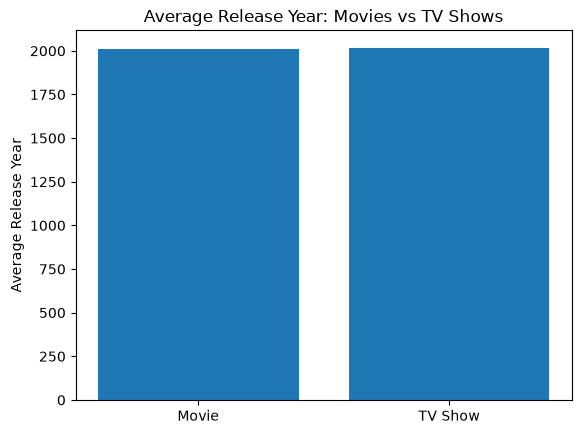

In [19]:
# Import Matplotlib for creating the comparison chart.
# We use it to visually compare the average release years of Movies and TV Shows.
import matplotlib.pyplot as plt

# Create the labels for the two content types.
# These labels will appear on the x-axis of the chart.
content_types = ["Movie", "TV Show"]

# Store the average release year for each content type.
# These values will be represented by the bars.
average_years = [movie_years.mean(), tv_years.mean()]

# Create a bar chart comparing the average release years.
# This makes the statistically significant difference easier to understand visually.
plt.bar(content_types, average_years)

# Add a title describing what the chart shows.
# This helps the viewer immediately understand the purpose of the visualization.
plt.title("Average Release Year: Movies vs TV Shows")

# Label the y-axis with the measured variable.
# This tells the viewer that the bar heights represent release years.
plt.ylabel("Average Release Year")

# Display the chart.
# This renders the visualization in the output.
plt.show()